In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.spatial import Voronoi, voronoi_plot_2d
import seaborn as sns

## Lectura del dataset

In [2]:
data=pd.read_csv("datos.csv")

In [3]:
#metadata de data
print(data.columns)

Index(['Sistema', 'Area', 'Generacion (MWh)', 'Importacion Total (MWh)',
       'Exportacion Total (MWh)', 'Intercambio neto entre Gerencias (MWh)',
       'Estimacion de Demanda por Balance (MWh)', 'Pronostico (MWh)',
       'Timestamp'],
      dtype='object')


In [4]:
data["Timestamp"]

0         01/01/2020 00:00
1         01/01/2020 01:00
2         01/01/2020 02:00
3         01/01/2020 03:00
4         01/01/2020 04:00
                ...       
373763    30/09/2024 19:00
373764    30/09/2024 20:00
373765    30/09/2024 21:00
373766    30/09/2024 22:00
373767    30/09/2024 23:00
Name: Timestamp, Length: 373768, dtype: object

## Separando los datos

In [5]:
time = data["Timestamp"]
time = pd.to_datetime(time, format="%d/%m/%Y %H:%M", dayfirst=True)
print(time)
#obteniendo los anios
years = time.dt.year.unique()
#agregando una columna con el anio
data["Year"] = time.dt.year
#obteniendo los meses
months = time.dt.month.unique()
#agregando una columna con el mes
data["Month"] = time.dt.month
#obteniendo los dias
days = time.dt.day.unique()
#agregando una columna con el dia
data["Day"] = time.dt.day
#obteniendo las horas
hours = time.dt.hour.unique()
#agregando una columna con la hora
data["Hour"] = time.dt.hour
#obteniendo los minutos
minutes = time.dt.minute.unique()
#agregando una columna con el minuto
data["Minute"] = time.dt.minute
#obteniendo los segundos
seconds = time.dt.second.unique()
#agregando una columna con el segundo
data["Second"] = time.dt.second
#obteniendo los microsegundos
microseconds = time.dt.microsecond.unique()
#agregando una columna con el microsegundo
data["Microsecond"] = time.dt.microsecond
#eliminando la columna Timestamp
#data.drop(columns=["Timestamp"], inplace=True)


0        2020-01-01 00:00:00
1        2020-01-01 01:00:00
2        2020-01-01 02:00:00
3        2020-01-01 03:00:00
4        2020-01-01 04:00:00
                 ...        
373763   2024-09-30 19:00:00
373764   2024-09-30 20:00:00
373765   2024-09-30 21:00:00
373766   2024-09-30 22:00:00
373767   2024-09-30 23:00:00
Name: Timestamp, Length: 373768, dtype: datetime64[ns]


In [6]:
print(years)

[2020 2021 2022 2023 2024]


In [7]:
#separando los datos por anio
years_data = {}
for year in years:
    years_data[year] = data[time.dt.year == year]
data_2020 = years_data[2020]
data_2021 = years_data[2021]
data_2022 = years_data[2022]
data_2023 = years_data[2023]


In [8]:
print(data)

       Sistema Area  Generacion (MWh)  Importacion Total (MWh)   
0          BCA  BCA        1124.16477                121.97846  \
1          BCA  BCA        1053.94972                 83.21267   
2          BCA  BCA        1047.20819                107.04241   
3          BCA  BCA        1042.45775                115.12048   
4          BCA  BCA        1026.56176                114.05929   
...        ...  ...               ...                      ...   
373763     SIN  PEN        1690.08687                  0.00000   
373764     SIN  PEN        1626.89274                  0.00000   
373765     SIN  PEN        1627.05534                  0.00000   
373766     SIN  PEN        1585.77332                  0.00000   
373767     SIN  PEN        1552.78983                  0.00000   

        Exportacion Total (MWh) Intercambio neto entre Gerencias (MWh)   
0                     220.99560                                    ---  \
1                     131.53384                            

In [9]:
print(data.describe())

       Generacion (MWh)  Importacion Total (MWh)  Exportacion Total (MWh)   
count     373768.000000            373768.000000            373768.000000  \
mean        4233.270784                25.926315                33.945439   
std         3230.271586                81.064669                65.570909   
min          108.129930                 0.000000                 0.000000   
25%         1492.845863                 0.000000                 0.000000   
50%         3572.183925                 0.000000                 0.000000   
75%         6114.695265                 0.001490                44.536145   
max        14531.516620               979.746790               758.060340   

       Estimacion de Demanda por Balance (MWh)  Pronostico (MWh)   
count                            373768.000000     373768.000000  \
mean                               4225.251660       4325.747534   
std                                2742.205173       2830.681396   
min                               

In [10]:
print(data.notnull().sum())

Sistema                                    373768
Area                                       373768
Generacion (MWh)                           373768
Importacion Total (MWh)                    373768
Exportacion Total (MWh)                    373768
Intercambio neto entre Gerencias (MWh)     373768
Estimacion de Demanda por Balance (MWh)    373768
Pronostico (MWh)                           373768
Timestamp                                  373768
Year                                       373768
Month                                      373768
Day                                        373768
Hour                                       373768
Minute                                     373768
Second                                     373768
Microsecond                                373768
dtype: int64


## Valores unicos

In [11]:
print(data.nunique())

Sistema                                         3
Area                                            9
Generacion (MWh)                           373684
Importacion Total (MWh)                     79148
Exportacion Total (MWh)                    128446
Intercambio neto entre Gerencias (MWh)     281465
Estimacion de Demanda por Balance (MWh)    373671
Pronostico (MWh)                           364009
Timestamp                                   41592
Year                                            5
Month                                          12
Day                                            31
Hour                                           24
Minute                                          1
Second                                          1
Microsecond                                     1
dtype: int64



In [12]:
#imprimiendo los valores de sistemas
areas = data["Area"].unique()
print(areas)

['BCA' 'BCS' 'CEN' 'NES' 'NOR' 'NTE' 'OCC' 'ORI' 'PEN']


Se entiende por:
BCA: Baja california
BCS: Baja california Sur
Cen: Centro
Nes: Noreste
Nor: Noroeste
Nte: norte
Occ: occidente
Ori: oriente
Pen: peninsula
sin embargo no se considera el sistema mulegue 
https://base.energia.gob.mx/prodesen22/Capitulo5.pdf?utm_source

mas actual: https://base.energia.gob.mx/PRODESEN2024/prodesen24-38A1.PDF
https://www.gob.mx/cms/uploads/attachment/file/475497/PRODESEN_V.pdf


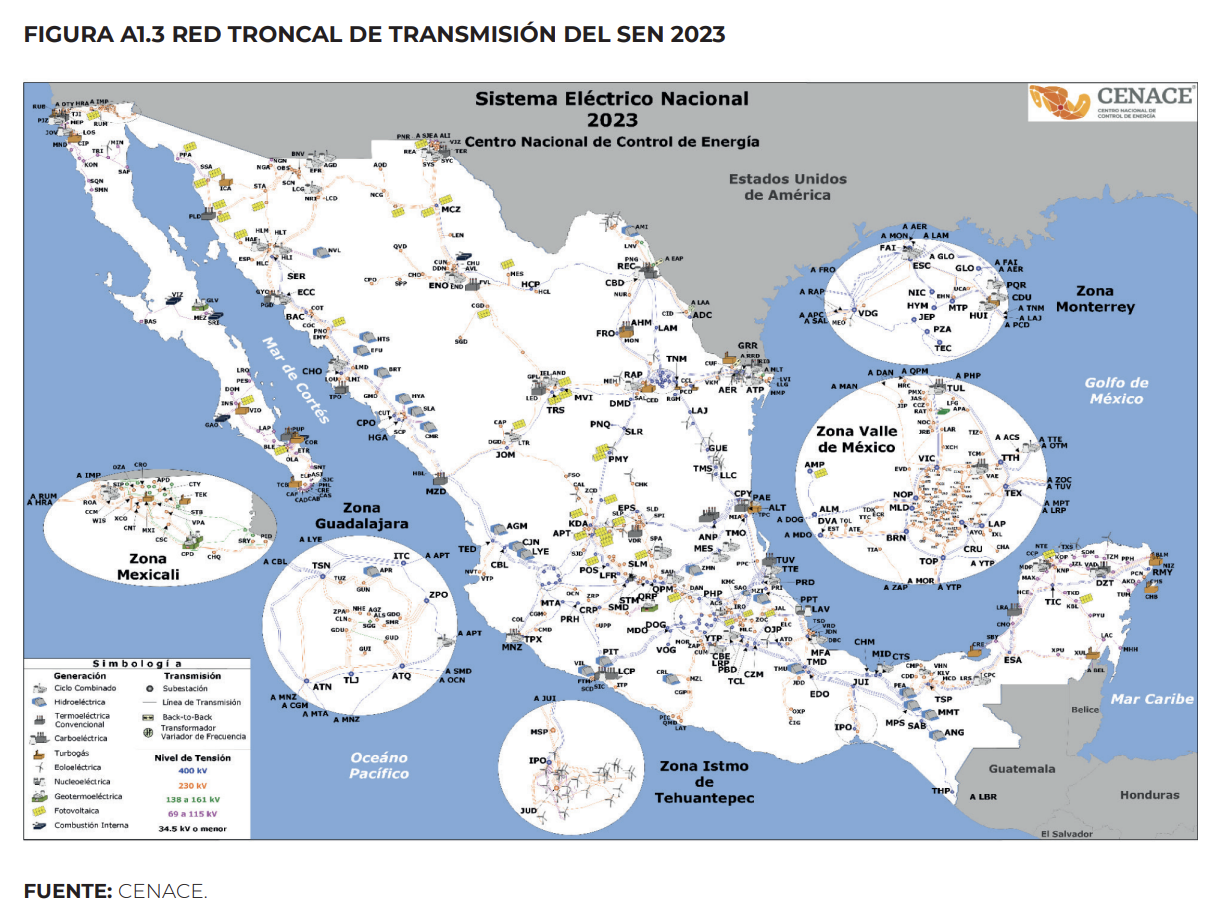

In [13]:
sistemas = data["Sistema"].unique()
print(sistemas)

['BCA' 'BCS' 'SIN']


Se consideran estos tres datos ya que el sistema electrico nacional se encuentran estos sistemas que no se encuentran conectados.

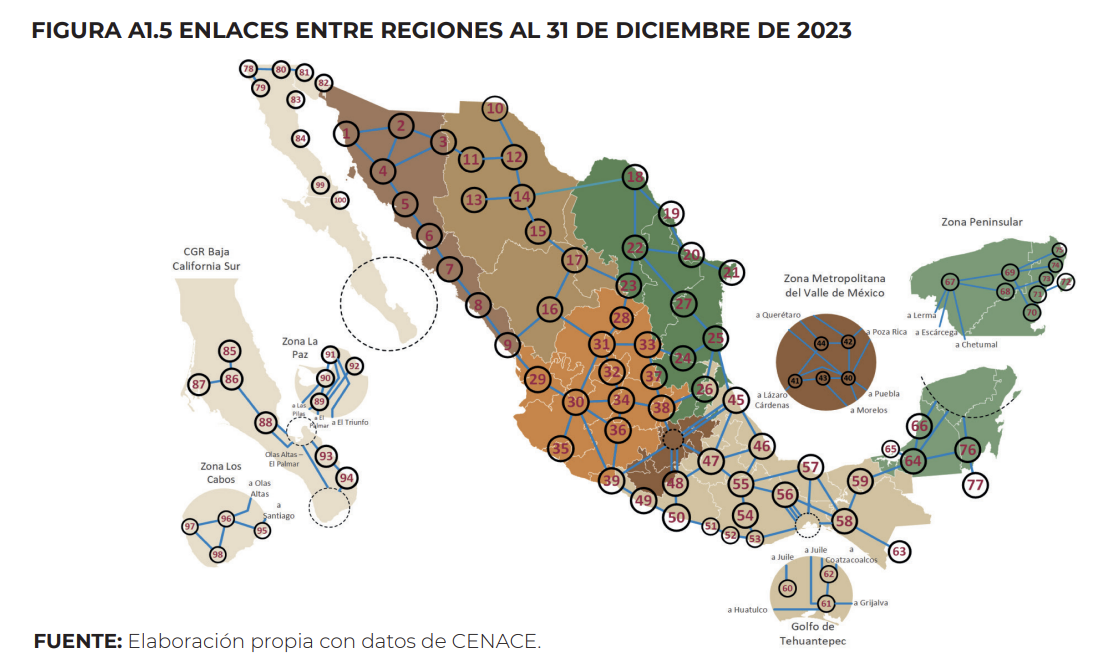

In [14]:
print(data_2020.shape)
print(data_2021.shape)
print(data_2022.shape)
print(data_2023.shape)

(79045, 16)
(78061, 16)
(78643, 16)
(78837, 16)


In [15]:
data["fecha_hora"] = pd.to_datetime(data[["Year", "Month", "Day", "Hour"]])
agrupado = data.groupby(["fecha_hora", "Area"])["Generacion (MWh)"].sum().reset_index()

In [16]:
print(data.columns)

Index(['Sistema', 'Area', 'Generacion (MWh)', 'Importacion Total (MWh)',
       'Exportacion Total (MWh)', 'Intercambio neto entre Gerencias (MWh)',
       'Estimacion de Demanda por Balance (MWh)', 'Pronostico (MWh)',
       'Timestamp', 'Year', 'Month', 'Day', 'Hour', 'Minute', 'Second',
       'Microsecond', 'fecha_hora'],
      dtype='object')


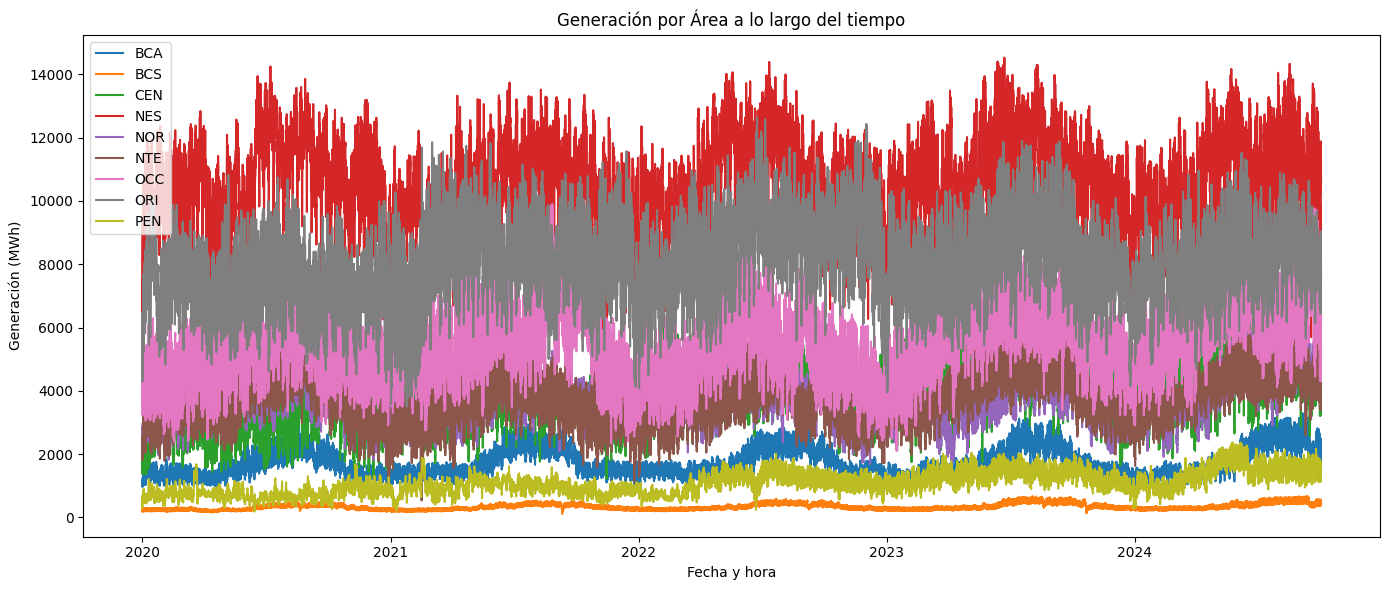

In [17]:
plt.figure(figsize=(14, 6))

for area in agrupado["Area"].unique():
    subset = agrupado[agrupado["Area"] == area]
    plt.plot(subset["fecha_hora"], subset["Generacion (MWh)"], label=area)

plt.title("Generación por Área a lo largo del tiempo")
plt.xlabel("Fecha y hora")
plt.ylabel("Generación (MWh)")
plt.legend()
plt.tight_layout()
plt.show()


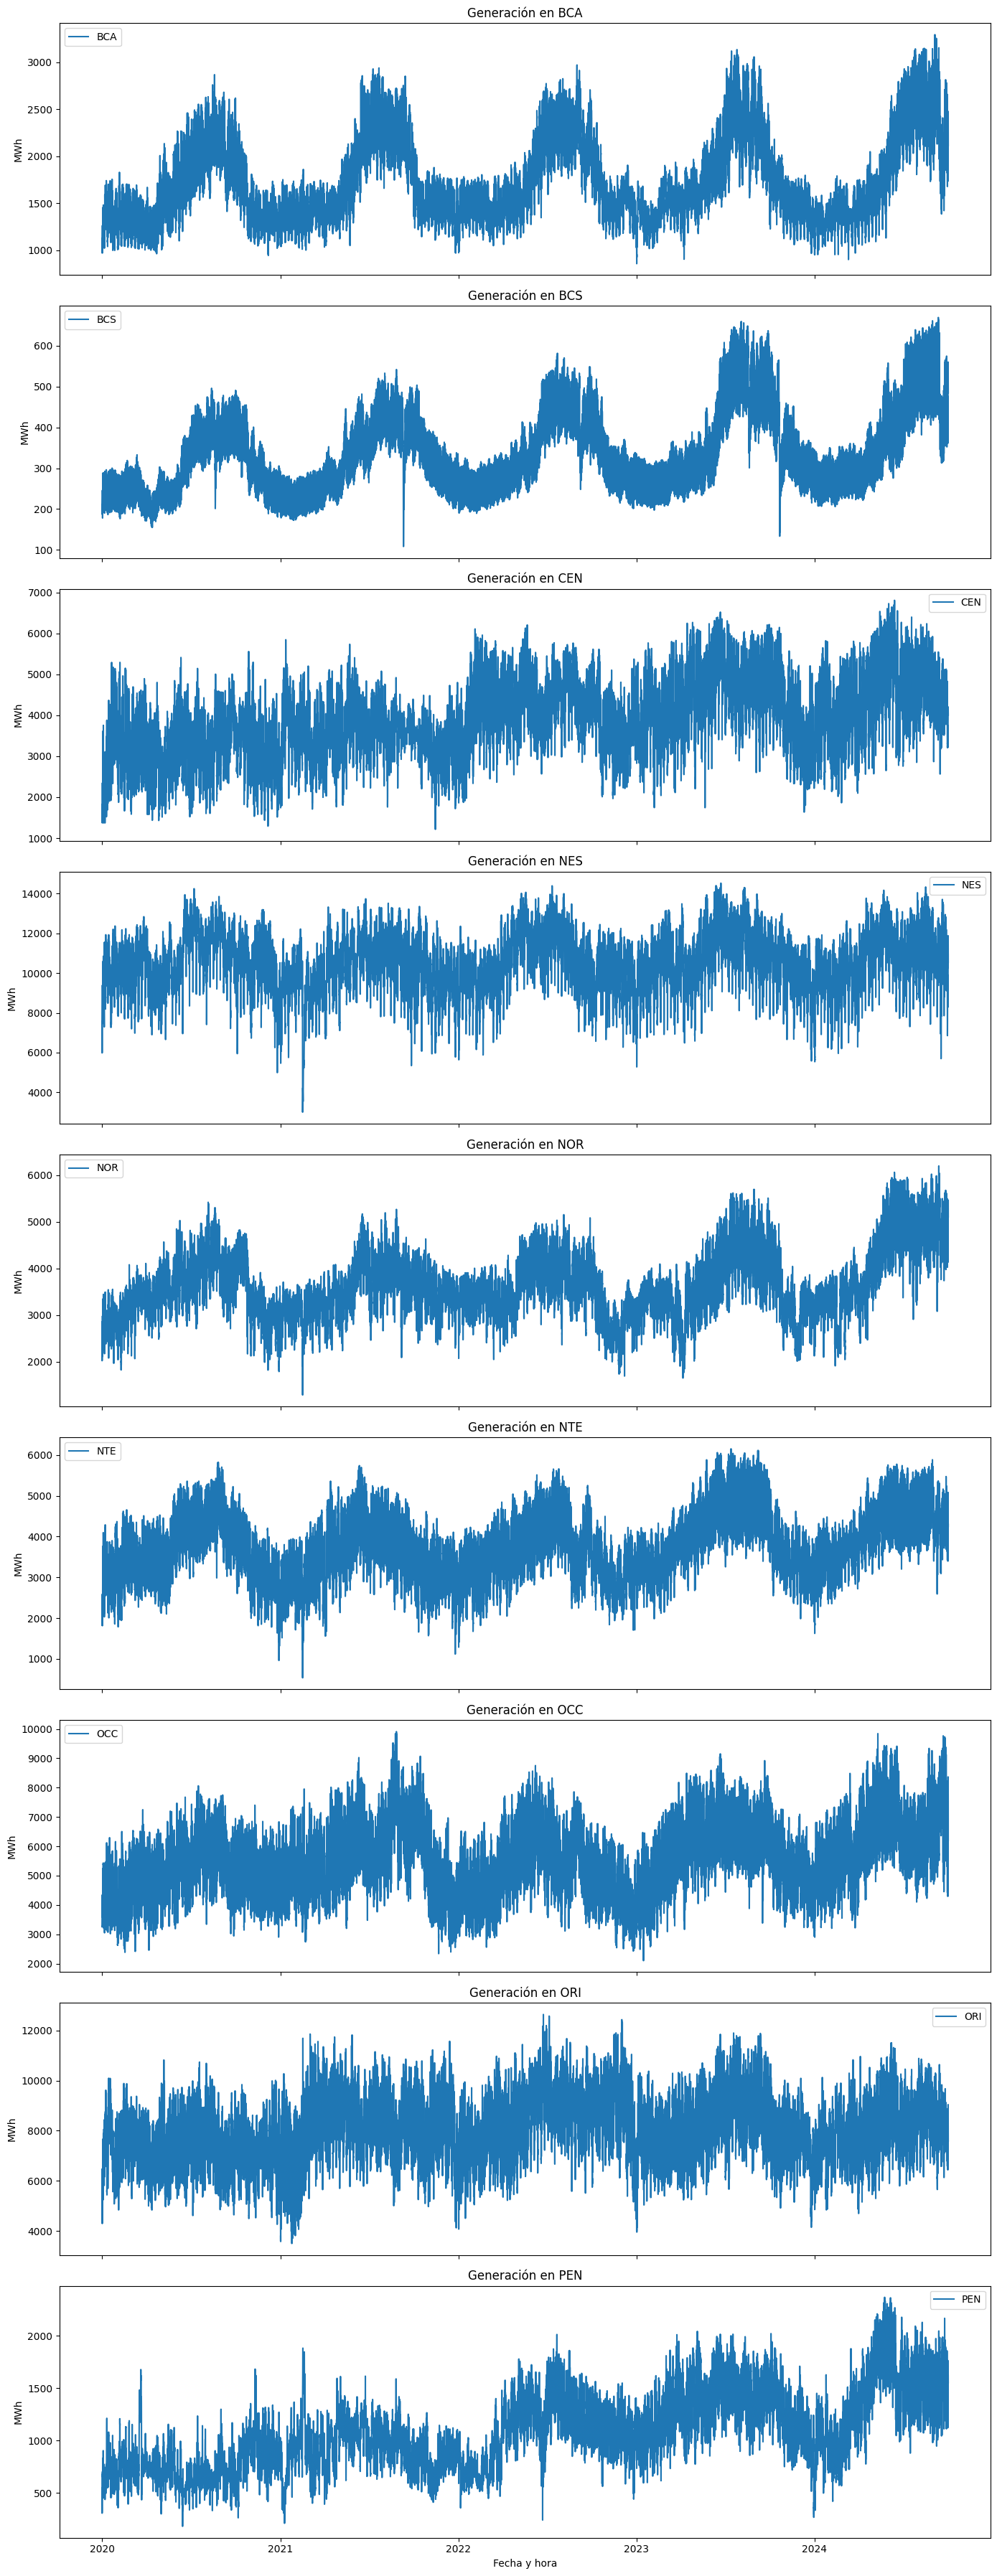

In [18]:
areas = agrupado["Area"].unique()
num_areas = len(areas)


fig, axs = plt.subplots(num_areas, 1, figsize=(14, 4 * num_areas), sharex=True)


if num_areas == 1:
    axs = [axs]


for i, area in enumerate(areas):
    subset = agrupado[agrupado["Area"] == area]
    axs[i].plot(subset["fecha_hora"], subset["Generacion (MWh)"], label=area)
    axs[i].set_title(f"Generación en {area}")
    axs[i].set_ylabel("MWh")
    axs[i].legend()

plt.xlabel("Fecha y hora")
plt.tight_layout()
plt.show()

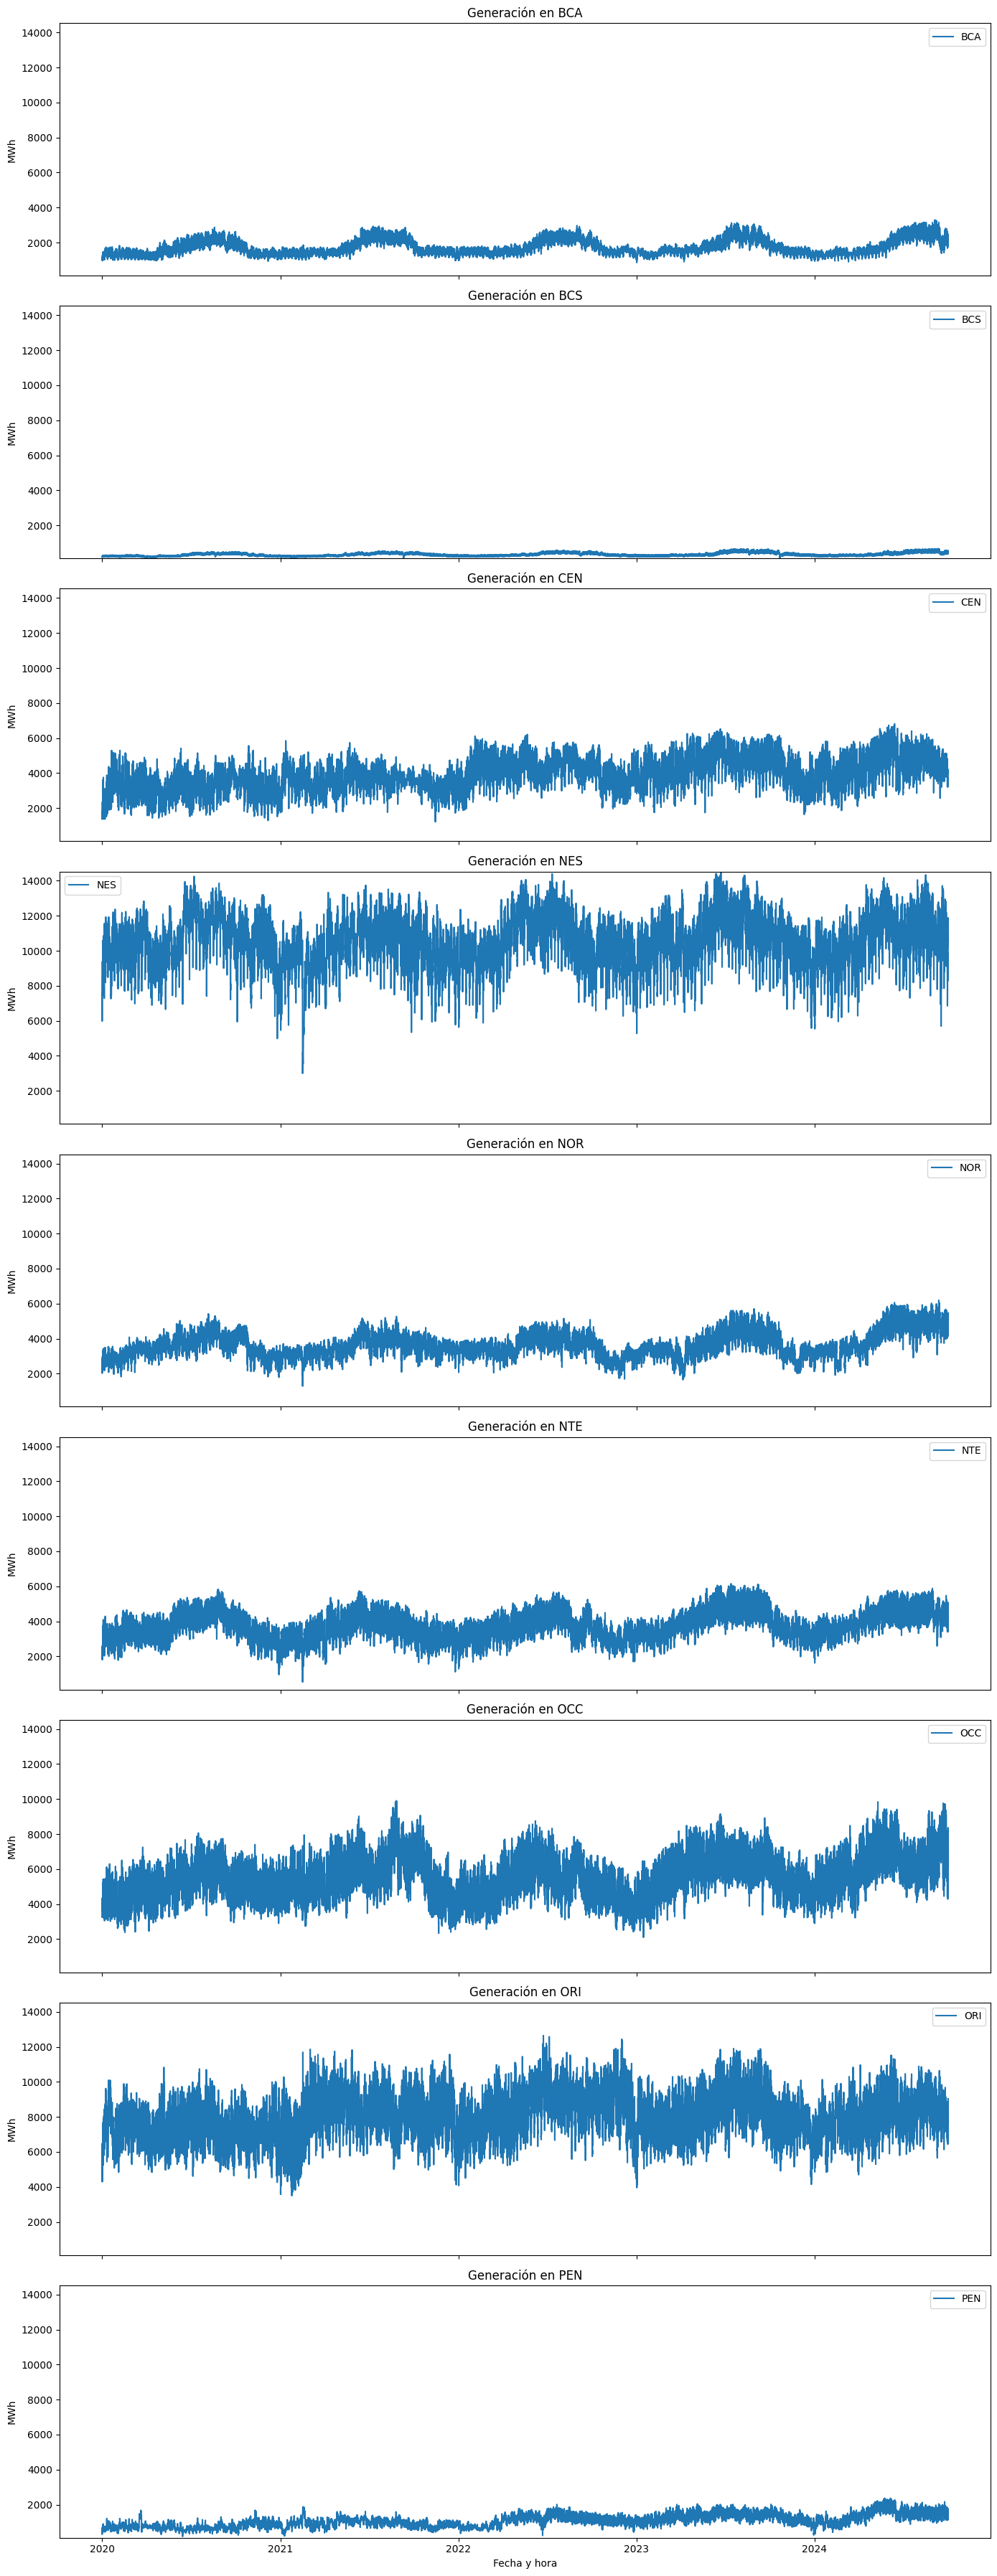

In [19]:
areas = agrupado["Area"].unique()
num_areas = len(areas)

# Obtener el mismo rango de valores Y para todos (mínimo y máximo global)
ymin = agrupado["Generacion (MWh)"].min()
ymax = agrupado["Generacion (MWh)"].max()

# Crear subplots
fig, axs = plt.subplots(num_areas, 1, figsize=(14, 4 * num_areas), sharex=True)

# Asegurarse de que axs sea iterable
if num_areas == 1:
    axs = [axs]

# Graficar por área
for i, area in enumerate(areas):
    subset = agrupado[agrupado["Area"] == area]
    axs[i].plot(subset["fecha_hora"], subset["Generacion (MWh)"], label=area)
    axs[i].set_ylim(ymin, ymax)  # Misma escala en eje Y
    axs[i].set_title(f"Generación en {area}")
    axs[i].set_ylabel("MWh")
    axs[i].legend()

plt.xlabel("Fecha y hora")
plt.tight_layout()
plt.show()

## Prueba de Dickey-Fuller Aumentada (ADF)

In [20]:
from statsmodels.tsa.stattools import adfuller

serie = subset["Generacion (MWh)"].dropna()
resultado = adfuller(serie)

print("ADF Statistic:", resultado[0])
print("p-value:", resultado[1])


ADF Statistic: -6.881321477793451
p-value: 1.4309949865552156e-09


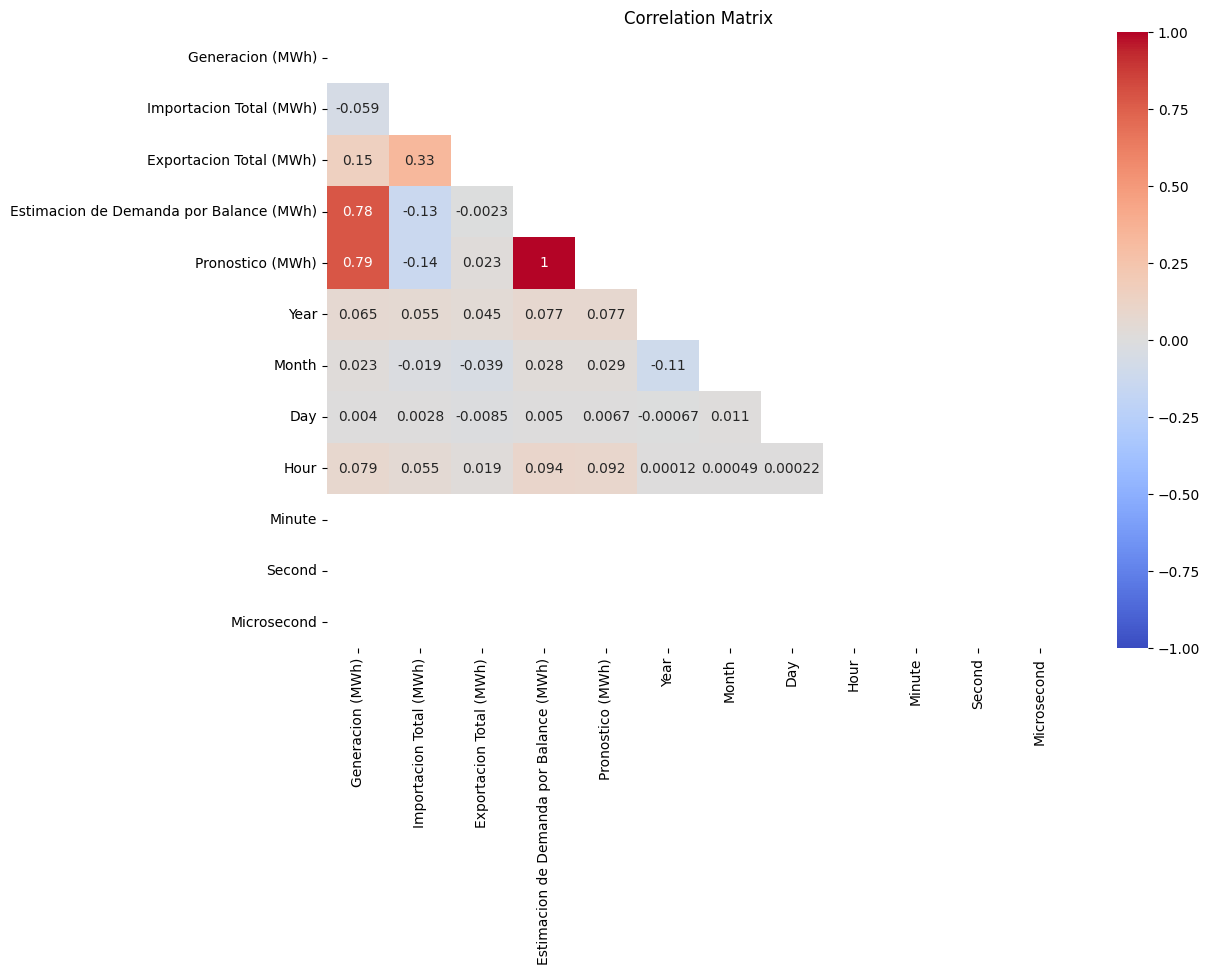

In [21]:
numeric_data = data.select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1
)
plt.title('Correlation Matrix')
plt.show()